In [ ]:
!pip install wfdb torch numpy pandas matplotlib scikit-learn tqdm

In [ ]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [ ]:
wfdb.dl_database('mitdb', dl_dir='mitdb')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [ ]:
records = ['100', '101', '102']

signals = []
labels = []

window_size = 128

label_map = {
    'N': 0,
    'V': 1,
    'A': 2
}

for record_name in records:

    record = wfdb.rdrecord(f'mitdb/{record_name}')
    annotation = wfdb.rdann(f'mitdb/{record_name}', 'atr')

    signal = record.p_signal[:, 0]

    for i, sample in enumerate(annotation.sample):

        symbol = annotation.symbol[i]

        if symbol in label_map:

            if sample-window_size >= 0 and sample+window_size < len(signal):

                beat = signal[sample-window_size : sample+window_size]

                signals.append(beat)

                labels.append(label_map[symbol])

In [ ]:
X = np.array(signals)
y = np.array(labels)

print(X.shape)
print(y.shape)

(4236, 256)
(4236,)


In [ ]:
X = (X - np.mean(X, axis=1, keepdims=True)) / \
    (np.std(X, axis=1, keepdims=True) + 1e-8)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
class ECGDataset(Dataset):

    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)

        return x, y

In [ ]:
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [ ]:
class AttentionBlock(nn.Module):

    def __init__(self, d_model, nhead):

        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            batch_first=True
        )

    def forward(self, x):

        attn_output, attn_weights = self.attention(
            x,
            x,
            x,
            need_weights=True
        )

        return attn_output, attn_weights

In [ ]:
class CNNTransformer(nn.Module):

    def __init__(
        self,
        d_model=64,
        nhead=4,
        num_layers=2,
        num_classes=3
    ):

        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                d_model,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2)
        )

        self.attention_block = AttentionBlock(
            d_model=d_model,
            nhead=nhead

        )


        # Classifier
        self.classifier = nn.Sequential(

            nn.Linear(d_model, 64),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        # (batch, seq)
        x = x.unsqueeze(1)

        # CNN
        x = self.cnn(x)

        # (batch, channels, seq)
        x = x.permute(0, 2, 1)

        # attn
        x, attn_weights = self.attention_block(x)

        # Global pooling
        x = x.mean(dim=1)

        return self.classifier(x), attn_weights

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNTransformer().to(device)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 30

for epoch in range(epochs):

    model.train()

    total_loss = 0

    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs, _ = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        # Predictions
        _, predicted = torch.max(outputs, 1)

        # Count correct predictions
        correct += (predicted == y_batch).sum().item()

        total += y_batch.size(0)

    # Epoch accuracy
    accuracy = correct / total

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {total_loss/len(train_loader):.4f}, "
        f"Accuracy: {accuracy:.4f}"
    )

Epoch 1, Loss: 0.1139, Accuracy: 0.9885
Epoch 2, Loss: 0.0277, Accuracy: 0.9932
Epoch 3, Loss: 0.2437, Accuracy: 0.9847
Epoch 4, Loss: 0.0561, Accuracy: 0.9891
Epoch 5, Loss: 0.0167, Accuracy: 0.9968
Epoch 6, Loss: 0.0251, Accuracy: 0.9920
Epoch 7, Loss: 0.0275, Accuracy: 0.9906
Epoch 8, Loss: 0.0246, Accuracy: 0.9941
Epoch 9, Loss: 0.0180, Accuracy: 0.9953
Epoch 10, Loss: 0.2924, Accuracy: 0.9537
Epoch 11, Loss: 0.0813, Accuracy: 0.9891
Epoch 12, Loss: 0.0585, Accuracy: 0.9838
Epoch 13, Loss: 0.0293, Accuracy: 0.9965
Epoch 14, Loss: 0.0288, Accuracy: 0.9932
Epoch 15, Loss: 0.0270, Accuracy: 0.9920
Epoch 16, Loss: 0.0198, Accuracy: 0.9956
Epoch 17, Loss: 0.0344, Accuracy: 0.9909
Epoch 18, Loss: 0.0255, Accuracy: 0.9938
Epoch 19, Loss: 0.0120, Accuracy: 0.9970
Epoch 20, Loss: 0.0134, Accuracy: 0.9965
Epoch 21, Loss: 0.0184, Accuracy: 0.9953
Epoch 22, Loss: 0.0101, Accuracy: 0.9965
Epoch 23, Loss: 0.0080, Accuracy: 0.9979
Epoch 24, Loss: 0.0042, Accuracy: 0.9985
Epoch 25, Loss: 0.0027, A

In [ ]:
predictions = []
true_labels = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs, attention = model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            y_batch.numpy()
        )

In [ ]:
print(np.unique(true_labels))
print(np.unique(predictions))

[0 1 2]
[0 1 2]


In [ ]:
unique, counts = np.unique(predictions,return_counts=True)
print("Prediction Distribution:")
print(dict(zip(unique, counts)))


Prediction Distribution:
{np.int64(0): np.int64(824), np.int64(1): np.int64(1), np.int64(2): np.int64(23)}


In [ ]:
unique, counts = np.unique(true_labels, return_counts=True)

print("True Label Distribution:")
print(dict(zip(unique, counts)))

True Label Distribution:
{np.int64(0): np.int64(840), np.int64(1): np.int64(1), np.int64(2): np.int64(7)}


In [ ]:
print(classification_report(
    true_labels,
    predictions,
    labels=[0,1,2],
    target_names=[
        'Normal',
        'PVC',
        'APB'
    ],
    zero_division=0
))

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       840
         PVC       1.00      1.00      1.00         1
         APB       0.22      0.71      0.33         7

    accuracy                           0.98       848
   macro avg       0.74      0.90      0.77       848
weighted avg       0.99      0.98      0.98       848



In [ ]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(
    true_labels,
    predictions
)

print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

Matthews Correlation Coefficient (MCC): 0.4255


Classes present: [0 1 2]
ROC-AUC Score: 0.8238


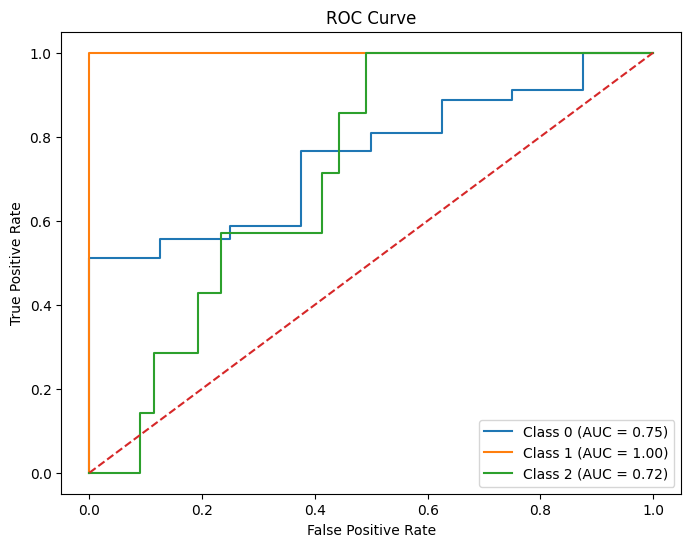

In [ ]:
# Convert probabilities
y_probs = np.array(y_probs)

# Find classes present
present_classes = np.unique(true_labels)

print("Classes present:", present_classes)

# Binarize labels
y_test_bin = label_binarize(
    true_labels,
    classes=present_classes
)

# Select matching probabilities
y_probs_selected = y_probs[:, present_classes]

# Compute ROC-AUC
roc_auc = roc_auc_score(
    y_test_bin,
    y_probs_selected,
    multi_class='ovr'
)

print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot curves
plt.figure(figsize=(8,6))

for idx, cls in enumerate(present_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, idx],
        y_probs_selected[:, idx]
    )

    roc_score = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {cls} (AUC = {roc_score:.2f})'
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
cm = confusion_matrix(
    true_labels,
    predictions
)

print(cm)

[[822   0  18]
 [  0   1   0]
 [  2   0   5]]


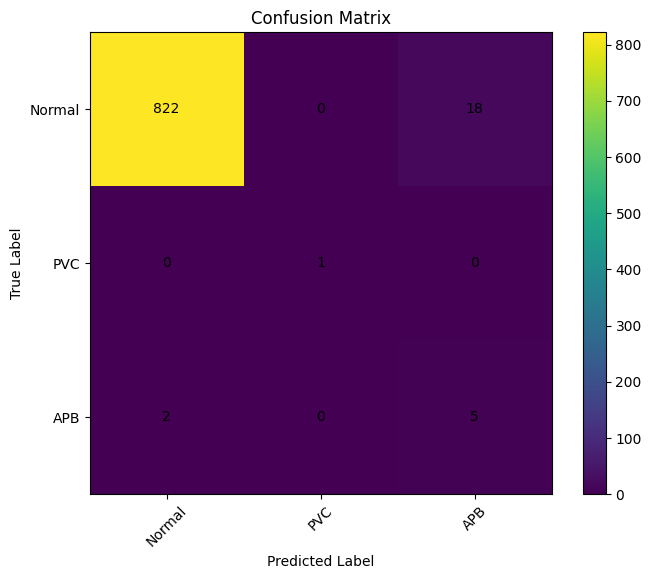

In [ ]:
class_names = [
    'Normal',
    'PVC',
    'APB'
]

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

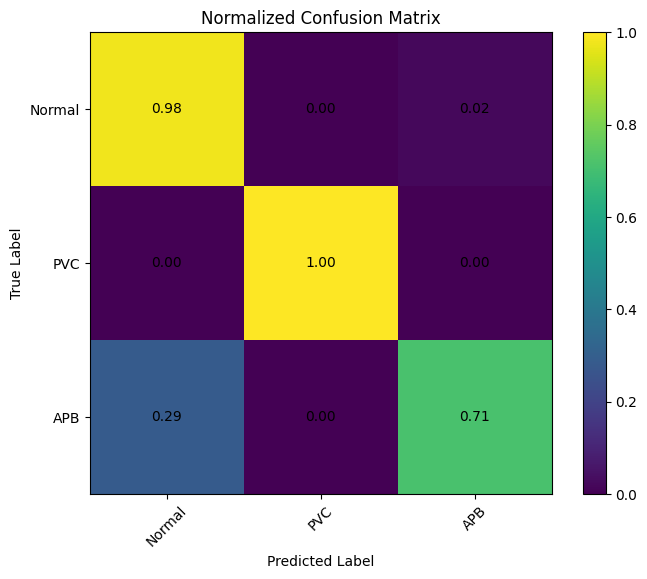

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

plt.imshow(cm_normalized)

plt.title("Normalized Confusion Matrix")

plt.colorbar()

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.show()

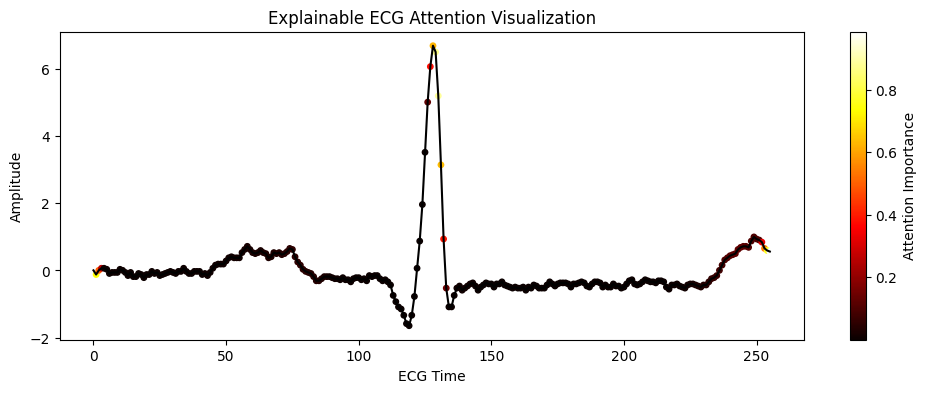

In [ ]:
# Take average attention across heads
attention_map = attention[0].mean(axis=0).cpu().detach().numpy()

# Normalize attention
attention_map = attention_map / attention_map.max()

# Original ECG
sample_signal = X_test[5]

# Resize attention to ECG length
attention_resized = np.interp(
    np.linspace(0, len(attention_map)-1, len(sample_signal)),
    np.arange(len(attention_map)),
    attention_map
)

plt.figure(figsize=(12,4))

plt.plot(sample_signal, color='black', linewidth=1.5)

# Overlay attention
plt.scatter(
    np.arange(len(sample_signal)),
    sample_signal,
    c=attention_resized,
    cmap='hot',
    s=15
)

plt.colorbar(label='Attention Importance')

plt.title("Explainable ECG Attention Visualization")

plt.xlabel("ECG Time")

plt.ylabel("Amplitude")

plt.show()